<a href="https://colab.research.google.com/github/epmbanten/Tugas-AI-602225073-Dody-Suhendra/blob/main/TrainModel4EnergyForecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Langkah 1: Notebook Training**

In [2]:
# ==========================================
# TAHAP 1.1: PERSAPAN LIBRARIES & IDENTITAS
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from datetime import datetime
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, BatchNormalization

print('Program start')

student_name = 'Dody Suhendra'
student_id = '6022251073'

current_time = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
print(f'Hello, {student_name} ({student_id}) !')
print(f'The current time is: {current_time}')

# ==========================================
# TAHAP 1.2: LOADING DATASET
# ==========================================

run_from_colab = False
data_filename = 'AEP_hourly.csv'

if (run_from_colab):
    from google.colab import drive
    drive.mount('/content/drive')
    df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/' + data_filename)
else:
    df = pd.read_csv(data_filename)

# Menampilkan data awal
print("\nData Awal:")
print(df.head())

Program start
Hello, Dody Suhendra (6022251073) !
The current time is: 2026-06-11 12:47:19

Data Awal:
              Datetime   AEP_MW
0  2004-12-31 01:00:00  13478.0
1  2004-12-31 02:00:00  12865.0
2  2004-12-31 03:00:00  12577.0
3  2004-12-31 04:00:00  12517.0
4  2004-12-31 05:00:00  12670.0


**Langkah 2: Pemilihan Data & Sub-Sampling**

In [3]:
# ==========================================
# Langkah 2: PEMILIHAN DATA & SUB-SAMPLING
# ==========================================

# 1. Konversi kolom Datetime menjadi tipe datetime dan urutkan data
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values(by='Datetime')

# 2. Filter data: Hanya ambil data setelah tanggal 2011-12-31 23:00:00
df = df[df['Datetime'] > '2011-12-31 23:00:00']

# 3. Sub-Sampling Data: Ambil data setiap kelipatan 6 jam
start = 0
step = 6
df = df[start::step]

# 4. Memisahkan kolom Datetime sebagai indeks waktu untuk plotting nanti
date_time = pd.to_datetime(df.pop('Datetime'))

# 5. Menampilkan statistik singkat data setelah di-sub-sample
print("Statistik Data Setelah Sub-Sampling:")
print(df.describe().transpose())

print("\n5 Data Teratas untuk Dataset:")
print(df.head())

Statistik Data Setelah Sub-Sampling:
         count          mean          std     min      25%      50%      75%  \
AEP_MW  9623.0  14960.109217  2455.917502  9712.0  13154.0  14632.0  16550.0   

            max  
AEP_MW  23412.0  

5 Data Teratas untuk Dataset:
        AEP_MW
54801  14181.0
72298  13623.0
72304  14183.0
72310  15364.0
72316  14672.0


**Langkah 3: Pemisahan Dataset (Splitting) & Normalisasi**

In [4]:
# =====================================================================
# TAHAP 3: PEMISAHAN DATASET (TRAINING & VALIDATION) & NORMALISASI
# =====================================================================

# 1. Menentukan rasio pembagian data
train_set = 0.8
val_set = 0.2

n = len(df)

# 2. Memisahkan data berdasarkan indeks (Time Series Split)
train_df = df[0: int(n * train_set)]
val_df = df[int(n * train_set): int(n * (train_set + val_set))]
test_df = df[int(n * (train_set + val_set)):]

num_features = df.shape[1]

print('--- Informasi Pembagian Dataset ---')
print('Total dataset         : ', n)
print('Dataset untuk training: ', len(train_df))
print('Dataset untuk validation: ', len(val_df))
print('Dataset untuk test    : ', len(test_df))

# 3. Normalisasi Dataset (Z-score Scaling)
train_mean = train_df.mean()
train_std = train_df.std()

val_mean = val_df.mean()
val_std = val_df.std()

test_mean = test_df.mean()
test_std = test_df.std()

# Proses transformasi data
train_df = (train_df - train_mean) / train_std
val_df = (val_df - val_mean) / val_std
# Mengantisipasi jika test_df kosong agar tidak menghasilkan error NaN/divbyzero
if len(test_df) > 0:
    test_df = (test_df - test_mean) / test_std

print('\n--- 5 Data Teratas Setelah Normalisasi ---')
print("Data Training:")
print(train_df.head())
print("\nData Validation:")
print(val_df.head())

--- Informasi Pembagian Dataset ---
Total dataset         :  9623
Dataset untuk training:  7698
Dataset untuk validation:  1925
Dataset untuk test    :  0

--- 5 Data Teratas Setelah Normalisasi ---
Data Training:
         AEP_MW
54801 -0.340905
72298 -0.568055
72304 -0.340091
72310  0.140669
72316 -0.141029

Data Validation:
          AEP_MW
113805 -1.178115
113763 -1.412522
113769 -1.054764
113775 -1.217046
113781 -1.119923


**Langkah 4: Dataset Windowing**

In [5]:
# =====================================================================
# TAHAP 4: DATASET WINDOWING
# =====================================================================

window_size = 80

def data_windowing(series, window_size):
    data_size = np.size(series)
    x_data = series[:window_size]
    y_data = series[window_size:window_size+1]

    for i in range(data_size - window_size - 1):
        x_data = np.vstack((x_data, series[i+1:window_size+i+1]))
        y_data = np.vstack((y_data, series[window_size+i+1:window_size+i+2]))

    x_data_tf = tf.expand_dims(x_data, axis=-1)
    y_data_tf = tf.expand_dims(y_data, axis=-1)
    return x_data_tf, y_data_tf

# Ekstrak nilai array dari dataframe
feature_data = 'AEP_MW'
train_series = train_df[feature_data].values
val_series = val_df[feature_data].values
test_series = test_df[feature_data].values

# Jalankan proses windowing
print("Memulai proses windowing... (Mohon tunggu sebentar)")
x_train_data, y_train_data = data_windowing(train_series, window_size)
x_val_data, y_val_data = data_windowing(val_series, window_size)

# Mengantisipasi jika test_set kosong agar tidak menyebabkan error vstack
if len(test_series) > window_size + 1:
    x_test_data, y_test_data = data_windowing(test_series, window_size)
else:
    x_test_data, y_test_data = None, None

print('Data windowing was successful')

# Tampilkan bentuk (shape) data untuk memastikan format tensor sudah benar
print("\n--- Shape Tensor Hasil Windowing ---")
print("x_train_data Shape:", x_train_data.shape)
print("y_train_data Shape:", y_train_data.shape)
print("x_val_data Shape:  ", x_val_data.shape)
print("y_val_data Shape:  ", y_val_data.shape)

Memulai proses windowing... (Mohon tunggu sebentar)
Data windowing was successful

--- Shape Tensor Hasil Windowing ---
x_train_data Shape: (7618, 80, 1)
y_train_data Shape: (7618, 1, 1)
x_val_data Shape:   (1845, 80, 1)
y_val_data Shape:   (1845, 1, 1)


**Langkah 5: Pembuatan Arsitektur Model AI**

In [6]:
# =====================================================================
# TAHAP 5: MEMBANGUN ARSITEKTUR MODEL (Slide 25)
# =====================================================================

model = tf.keras.Sequential([
    # Layer 1: Bidirectional LSTM pertama (mengembalikan sekuens lengkap untuk layer berikutnya)
    Bidirectional(LSTM(window_size, return_sequences=True)),

    # Layer 2: Bidirectional LSTM kedua (menggabungkan informasi sekuens)
    Bidirectional(LSTM(window_size)),

    # Layer 3: Batch Normalization untuk menstabilkan training
    BatchNormalization(),

    # Layer 4: Fully Connected Layer pertama dengan 100 neuron dan aktivasi Sigmoid
    Dense(100, activation='sigmoid'),

    # Layer 5: Batch Normalization kedua
    BatchNormalization(),

    # Layer 6: Dropout untuk regulerisasi agar tidak overfitting (memutus 25% neuron acak)
    Dropout(0.25),

    # Layer 7: Fully Connected Layer kedua dengan 20 neuron dan aktivasi Sigmoid
    Dense(20, activation='sigmoid'),

    # Layer 8: Output layer dengan 1 neuron (prediksi nilai kontinu AEP_MW)
    Dense(1)
])

print('Model created')

# Build model secara eksplisit agar kita bisa melihat summary strukturnya
model.build(input_shape=(None, window_size, 1))
model.summary()

Model created


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 80, 160)        │        52,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 160)            │       154,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160)            │           640 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        16,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,901 (882.43 KB)

 Trainable params: 225,381 (880.39 KB)

 Non-trainable params: 520 (2.03 KB)

**Langkah 6: Pelatihan Model (Training Process)**

In [7]:
# =====================================================================
# TAHAP 6: PROSES PELATHIAN MODEL (Slide 26)
# =====================================================================

# 1. Penentuan Epochs dan Batch Size
epochs = 1000
batch_size = int(0.1 * len(train_df))
print('Batch size: ', batch_size)

# 2. Definisi Callbacks
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_mae',
    factor=0.1,
    patience=50,
    min_lr=1e-7
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='mae',
    patience=80,
    restore_best_weights=True
)

# 3. Kompilasi Model
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-2)
model.compile(loss='huber', optimizer=optimizer, metrics=['mae'])

# 4. Eksekusi Training (Fit Model)
print("\nMemulai proses training model... (Proses ini membutuhkan waktu beberapa menit)")
model_history = model.fit(
    x_train_data,
    y_train_data,
    epochs=epochs,
    validation_data=[x_val_data, y_val_data],
    verbose=2,
    batch_size=batch_size,
    callbacks=[reduce_lr, early_stopping]
)

print('\nFinal MAE: {:.4f}'.format(np.min(model_history.history['mae'])))
print('End of training')

Batch size:  769

Memulai proses training model... (Proses ini membutuhkan waktu beberapa menit)
Epoch 1/1000
10/10 - 8s - 785ms/step - loss: 0.3262 - mae: 0.6826 - val_loss: 0.4142 - val_mae: 0.7917 - learning_rate: 0.0100
Epoch 2/1000
10/10 - 1s - 78ms/step - loss: 0.1600 - mae: 0.4543 - val_loss: 0.3567 - val_mae: 0.7237 - learning_rate: 0.0100
Epoch 3/1000
10/10 - 1s - 88ms/step - loss: 0.1432 - mae: 0.4271 - val_loss: 0.3969 - val_mae: 0.7522 - learning_rate: 0.0100
Epoch 4/1000
10/10 - 1s - 88ms/step - loss: 0.1172 - mae: 0.3841 - val_loss: 0.4062 - val_mae: 0.7621 - learning_rate: 0.0100
Epoch 5/1000
10/10 - 1s - 76ms/step - loss: 0.0991 - mae: 0.3505 - val_loss: 0.4180 - val_mae: 0.7747 - learning_rate: 0.0100
Epoch 6/1000
10/10 - 1s - 73ms/step - loss: 0.0918 - mae: 0.3366 - val_loss: 0.4258 - val_mae: 0.7827 - learning_rate: 0.0100
Epoch 7/1000
10/10 - 1s - 73ms/step - loss: 0.0880 - mae: 0.3287 - val_loss: 0.4193 - val_mae: 0.7763 - learning_rate: 0.0100
Epoch 8/1000
10/10 -

**Langkah 7: Plot Kurva Hasil Pelatihan & Simpan Model**

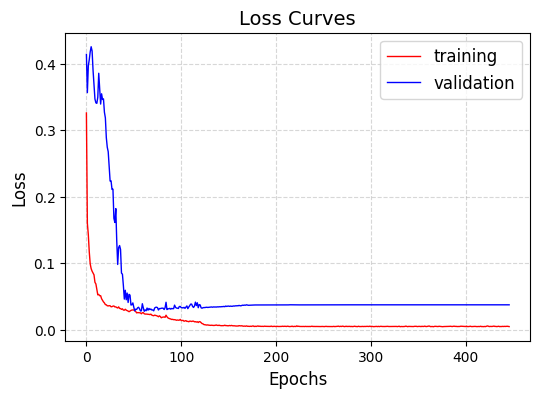

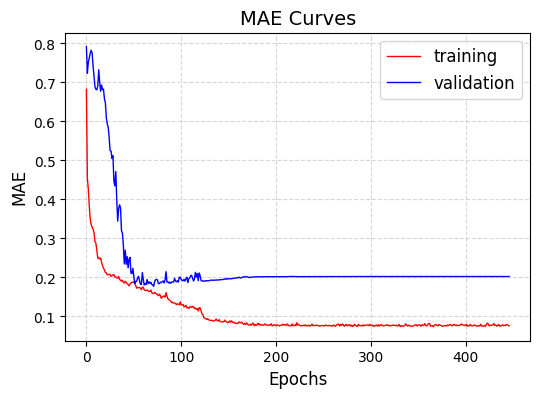

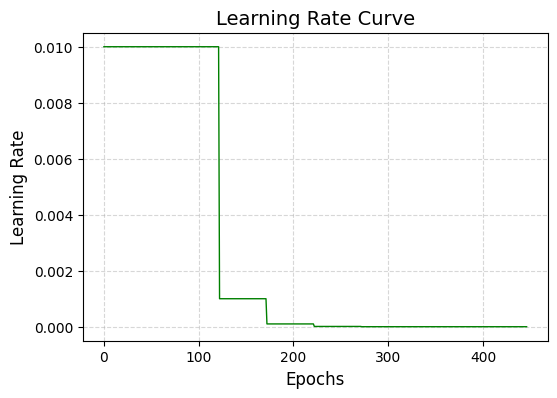


Model saved as: Energy Forecasting.keras
End of program


In [8]:
# =====================================================================
# TAHAP 4: PLOT KURVA HASIL PELATIHAN & SIMPAN MODEL (Slide 27-28)
# =====================================================================

# 1. Plot Kurva Huber Loss
plt.figure(figsize=[6, 4])
plt.plot(model_history.history['loss'], 'r', linewidth=1.0)
plt.plot(model_history.history['val_loss'], 'b', linewidth=1.0)
plt.legend(['training', 'validation'], fontsize=12)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Loss Curves', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 2. Plot Kurva MAE
plt.figure(figsize=[6, 4])
plt.plot(model_history.history['mae'], 'r', linewidth=1.0)
plt.plot(model_history.history['val_mae'], 'b', linewidth=1.0)
plt.legend(['training', 'validation'], fontsize=12)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.title('MAE Curves', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 3. Plot Kurva Perubahan Learning Rate
plt.figure(figsize=[6, 4])
plt.plot(model_history.history['learning_rate'], 'g', linewidth=1.0)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Learning Rate', fontsize=12)
plt.title('Learning Rate Curve', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 4. Menyimpan Model ke Format .keras
model_filename = 'Energy Forecasting.keras'
model.save(model_filename)

print('\nModel saved as:', model_filename)
print('End of program')